# Formatos de archivos de imagen

En este cuaderno vas a comparar varios formatos habituales de imagen para entender qué conservan, qué sacrifican y por qué esa decisión importa cuando armás un flujo de trabajo con imágenes.


## Objetivo

Distinguir formato de archivo, resolución y representación de color, y analizar cómo cambian el tamaño del archivo y la calidad visual según el método de compresión.

## Resultados de aprendizaje

Al finalizar este cuaderno, vas a poder:

- explicar la diferencia entre compresión con pérdida y compresión sin pérdida;
- comparar tamaños de archivo entre varios formatos;
- observar artefactos visuales en zonas recortadas de una imagen;
- justificar qué formato conviene para conservar originales, editar y entregar resultados.

## Relación con la secuencia

Este cuaderno se apoya en la introducción a OpenCV y espacios de color. Acá el foco ya no está en transformar el contenido de la imagen, sino en entender cómo se guarda ese contenido en disco.


## Módulos que vamos a usar

- `cv2`: para leer y guardar imágenes en distintos formatos.
- `matplotlib.pyplot`: para visualizar comparaciones.
- `pathlib.Path`: para trabajar con rutas de archivos.
- `tempfile`: para crear archivos temporales sin ensuciar la carpeta del proyecto.


In [1]:
from pathlib import Path
import tempfile

import cv2
import matplotlib.pyplot as plt

CARPETA_IMAGENES = Path("Imagenes")
ruta_imagen = CARPETA_IMAGENES / "globos.jpg"

imagen_bgr = cv2.imread(str(ruta_imagen), cv2.IMREAD_COLOR)
if imagen_bgr is None:
    raise FileNotFoundError(f"No se pudo leer la imagen: {ruta_imagen}")

imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
print(f"Dimensiones: {imagen_rgb.shape}")


Dimensiones: (1024, 1024, 3)


## 1. Imagen base y punto de partida

Vamos a usar una misma imagen para todos los experimentos. Eso permite que cualquier diferencia que veas al final se deba al formato de guardado y no a cambios en el contenido.


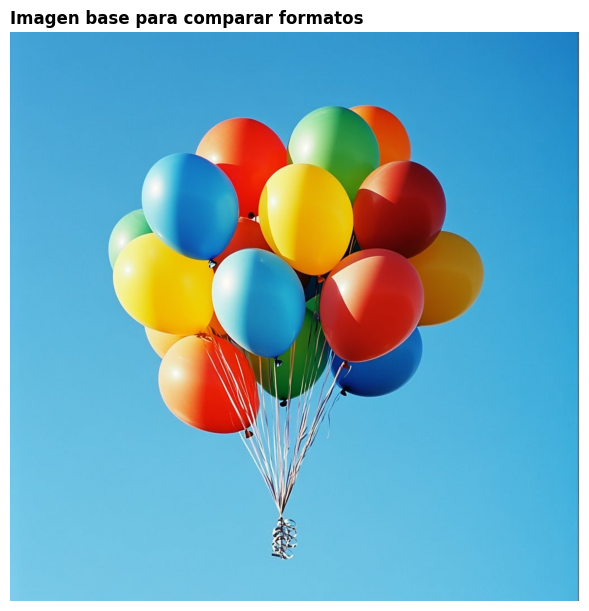

In [2]:
plt.figure(figsize=(9, 6), constrained_layout=True)
plt.imshow(imagen_rgb)
plt.title("Imagen base para comparar formatos", fontweight="bold", loc="left")
plt.axis("off")
plt.show()


Observá que todavía no estamos hablando de píxeles distintos ni de colores distintos. La imagen es la misma. Lo que va a cambiar es la forma en que se escribe en el archivo.


## 2. Guardar la misma imagen en varios formatos

Ahora vamos a guardar exactamente la misma imagen en distintos formatos. El objetivo es comparar el tamaño aproximado de cada archivo y relacionarlo con el tipo de compresión que usa.


In [3]:
formatos = [
    ("jpeg_calidad_alta.jpg", [cv2.IMWRITE_JPEG_QUALITY, 95]),
    ("jpeg_calidad_baja.jpg", [cv2.IMWRITE_JPEG_QUALITY, 35]),
    ("png.png", [cv2.IMWRITE_PNG_COMPRESSION, 3]),
    ("bmp.bmp", []),
    ("webp.webp", [cv2.IMWRITE_WEBP_QUALITY, 80]),
]

resultados = []

with tempfile.TemporaryDirectory() as carpeta_temporal:
    carpeta_temporal = Path(carpeta_temporal)

    for nombre_archivo, parametros in formatos:
        ruta_guardado = carpeta_temporal / nombre_archivo
        se_pudo_guardar = cv2.imwrite(str(ruta_guardado), imagen_bgr, parametros)

        if not se_pudo_guardar:
            resultados.append((nombre_archivo, "no disponible"))
            continue

        tamano_kb = ruta_guardado.stat().st_size / 1024
        resultados.append((nombre_archivo, round(tamano_kb, 1)))

    print(f"{'Archivo':<24} {'Tamaño aproximado (KB)':>24}")
    print("-" * 52)
    for nombre_archivo, tamano in resultados:
        print(f"{nombre_archivo:<24} {str(tamano):>24}")


Archivo                    Tamaño aproximado (KB)
----------------------------------------------------
jpeg_calidad_alta.jpg                       114.1
jpeg_calidad_baja.jpg                        36.5
png.png                                     651.4
bmp.bmp                                    3072.1
webp.webp                                    33.6


Fijate qué formatos generan archivos más livianos y cuáles conservan más información sin comprimir tanto. No hay un formato universalmente mejor: la elección depende del uso.


## 3. Comparar calidad visual en un recorte pequeño

Las pérdidas de calidad suelen verse mejor en zonas recortadas que en la imagen completa. Por eso vamos a mirar una región más chica y comparar una versión JPEG de alta calidad, una de baja calidad y una versión PNG.


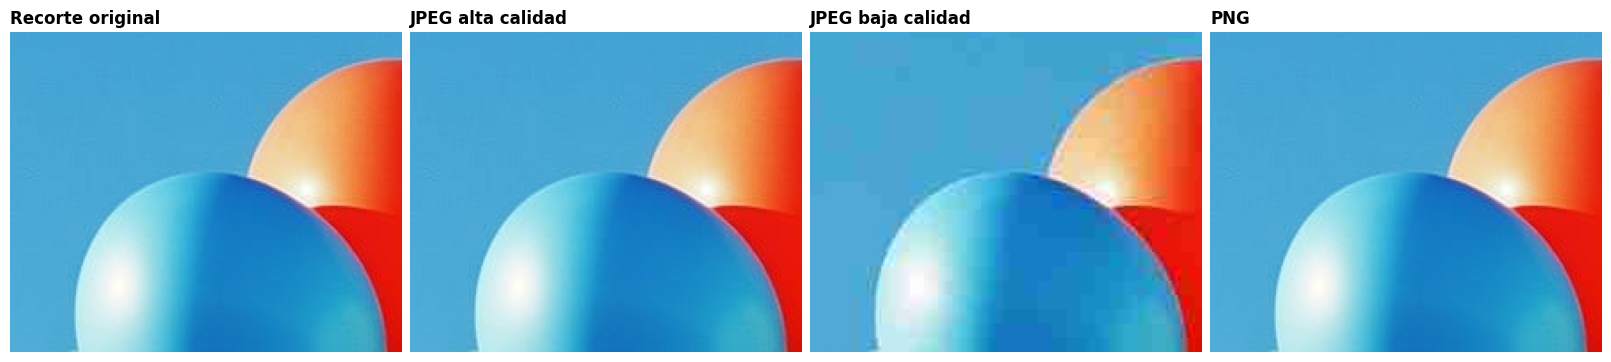

In [4]:
with tempfile.TemporaryDirectory() as carpeta_temporal:
    carpeta_temporal = Path(carpeta_temporal)

    ruta_jpeg_alta = carpeta_temporal / "alta.jpg"
    ruta_jpeg_baja = carpeta_temporal / "baja.jpg"
    ruta_png = carpeta_temporal / "imagen.png"

    cv2.imwrite(str(ruta_jpeg_alta), imagen_bgr, [cv2.IMWRITE_JPEG_QUALITY, 95])
    cv2.imwrite(str(ruta_jpeg_baja), imagen_bgr, [cv2.IMWRITE_JPEG_QUALITY, 20])
    cv2.imwrite(str(ruta_png), imagen_bgr, [cv2.IMWRITE_PNG_COMPRESSION, 3])

    jpeg_alta_rgb = cv2.cvtColor(cv2.imread(str(ruta_jpeg_alta)), cv2.COLOR_BGR2RGB)
    jpeg_baja_rgb = cv2.cvtColor(cv2.imread(str(ruta_jpeg_baja)), cv2.COLOR_BGR2RGB)
    png_rgb = cv2.cvtColor(cv2.imread(str(ruta_png)), cv2.COLOR_BGR2RGB)

fila_inicial, fila_final = 140, 320
columna_inicial, columna_final = 200, 420

recorte_original = imagen_rgb[fila_inicial:fila_final, columna_inicial:columna_final]
recorte_jpeg_alta = jpeg_alta_rgb[fila_inicial:fila_final, columna_inicial:columna_final]
recorte_jpeg_baja = jpeg_baja_rgb[fila_inicial:fila_final, columna_inicial:columna_final]
recorte_png = png_rgb[fila_inicial:fila_final, columna_inicial:columna_final]

fig, ejes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)

ejes[0].imshow(recorte_original)
ejes[0].set_title("Recorte original", fontweight="bold", loc="left")
ejes[0].axis("off")

ejes[1].imshow(recorte_jpeg_alta)
ejes[1].set_title("JPEG alta calidad", fontweight="bold", loc="left")
ejes[1].axis("off")

ejes[2].imshow(recorte_jpeg_baja)
ejes[2].set_title("JPEG baja calidad", fontweight="bold", loc="left")
ejes[2].axis("off")

ejes[3].imshow(recorte_png)
ejes[3].set_title("PNG", fontweight="bold", loc="left")
ejes[3].axis("off")

plt.show()


Observá sobre todo los bordes, las transiciones de color y las zonas con textura suave. En JPEG de baja calidad suelen aparecer bloques, ruido o degradaciones que no estaban en la imagen original.


## 4. Repetir una compresión con pérdida

Cuando una imagen JPEG se vuelve a guardar muchas veces, la degradación puede acumularse. Vamos a simular ese proceso para que se vea mejor.


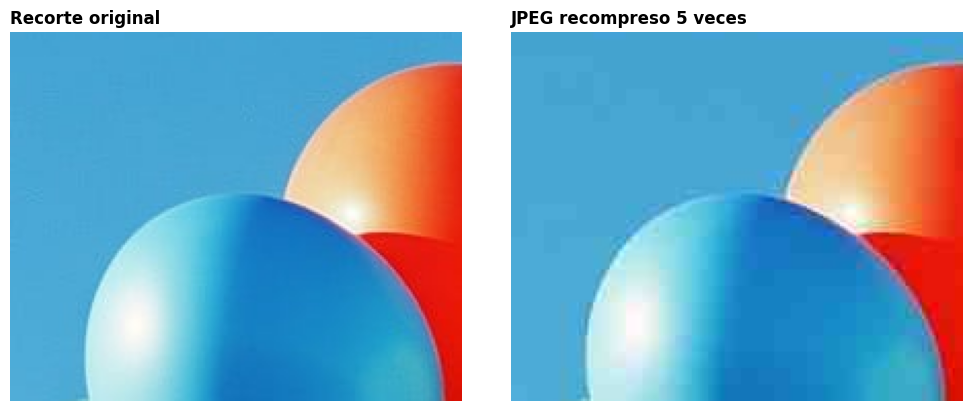

In [5]:
imagen_trabajo_bgr = imagen_bgr.copy()

with tempfile.TemporaryDirectory() as carpeta_temporal:
    carpeta_temporal = Path(carpeta_temporal)

    for indice in range(5):
        ruta_iteracion = carpeta_temporal / f"recompresion_{indice}.jpg"
        cv2.imwrite(str(ruta_iteracion), imagen_trabajo_bgr, [cv2.IMWRITE_JPEG_QUALITY, 25])
        imagen_trabajo_bgr = cv2.imread(str(ruta_iteracion), cv2.IMREAD_COLOR)

    imagen_recomprimida_rgb = cv2.cvtColor(imagen_trabajo_bgr, cv2.COLOR_BGR2RGB)

recorte_recomprimido = imagen_recomprimida_rgb[fila_inicial:fila_final, columna_inicial:columna_final]

fig, ejes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
ejes[0].imshow(recorte_original)
ejes[0].set_title("Recorte original", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(recorte_recomprimido)
ejes[1].set_title("JPEG recompreso 5 veces", fontweight="bold", loc="left")
ejes[1].axis("off")
plt.show()


Este experimento muestra por qué conviene conservar un original sin pérdida o con mínima pérdida. Si editás siempre sobre versiones ya degradadas, el error visual se acumula.


## Limitaciones y criterio de uso

Este cuaderno no agota todas las variantes de cada formato, pero sí deja una idea práctica:

- JPEG suele servir para compartir o publicar imágenes livianas;
- PNG conviene cuando querés preservar mejor bordes, gráficos o transparencia;
- formatos más pesados pueden ser útiles para archivo o edición intermedia.


## Actividad breve

Elegí una segunda imagen de la carpeta `Imagenes` y repetí esta comparación. Después respondé:

1. ¿qué formato te dio el archivo más liviano?
2. ¿en qué zonas se notó más la pérdida de calidad?
3. ¿qué formato usarías para conservar un original de trabajo y cuál usarías para compartir el resultado?


## Cierre

Guardar una imagen no es un detalle administrativo. También es una decisión técnica. El formato elegido puede afectar tamaño, calidad visual y posibilidades de edición posterior. Por eso conviene pensar el formato como parte del pipeline y no como un paso final sin importancia.
